# Claude CLI Traces Analysis

Queries BigQuery tenant `t_0c7a351603a24035a30e947c488688b2` for `claude-cli-*` workflow traces.

### Note on `prompt_tokens` inconsistency
Early instrumentation (pre ~Apr 20) recorded `prompt_tokens` as only **new** (uncached) input tokens,
while later versions record it as the **total** input tokens (including cache reads).
We detect this by checking if `cache_read_tokens > prompt_tokens` and compute
`total_input = prompt + cache_read + cache_creation` when that's the case.

In [1]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

client = bigquery.Client(project="fluent-radar-408119")
DATASET = "t_0c7a351603a24035a30e947c488688b2"
TABLE = f"{DATASET}.traces"

# Shared CTE: extracts per-inference-span token fields and normalises
# prompt_tokens to always mean "total input tokens".
INFERENCE_CTE = f"""
inference_spans AS (
  SELECT trace_id,
         CAST(JSON_VALUE(events, '$[2].attributes.prompt_tokens')         AS INT64) AS raw_prompt,
         CAST(JSON_VALUE(events, '$[2].attributes.completion_tokens')     AS INT64) AS completion_tokens,
         CAST(JSON_VALUE(events, '$[2].attributes.cache_read_tokens')     AS INT64) AS cache_read_tokens,
         CAST(JSON_VALUE(events, '$[2].attributes.cache_creation_tokens') AS INT64) AS cache_creation_tokens,
         -- Normalise: if raw_prompt < cache_read, it's \"new tokens only\" (old instrumentation)
         IF(
           CAST(JSON_VALUE(events, '$[2].attributes.prompt_tokens') AS INT64)
             < COALESCE(CAST(JSON_VALUE(events, '$[2].attributes.cache_read_tokens') AS INT64), 0),
           CAST(JSON_VALUE(events, '$[2].attributes.prompt_tokens') AS INT64)
             + COALESCE(CAST(JSON_VALUE(events, '$[2].attributes.cache_read_tokens') AS INT64), 0)
             + COALESCE(CAST(JSON_VALUE(events, '$[2].attributes.cache_creation_tokens') AS INT64), 0),
           CAST(JSON_VALUE(events, '$[2].attributes.prompt_tokens') AS INT64)
         ) AS total_input_tokens
  FROM `{TABLE}`
  WHERE start_time >= TIMESTAMP_SUB(CURRENT_TIMESTAMP(), INTERVAL 14 DAY)
    AND name LIKE 'Claude Inference%'
    AND JSON_VALUE(events, '$[2].attributes.completion_tokens') IS NOT NULL
)
"""

WORKFLOW_CTE = f"""
workflows AS (
  SELECT trace_id,
         JSON_VALUE(attributes, '$.entity[0].name') AS workflow_name,
         DATE(start_time) AS trace_date
  FROM `{TABLE}`
  WHERE start_time >= TIMESTAMP_SUB(CURRENT_TIMESTAMP(), INTERVAL 14 DAY)
    AND name = 'workflow'
    AND JSON_VALUE(attributes, '$.entity[0].name') LIKE 'claude-cli-%'
)
"""

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/google/auth/_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


---
## 1. Trace Counts

In [2]:
trace_counts_sql = f"""
SELECT
  JSON_VALUE(attributes, '$.entity[0].name') AS workflow_name,
  DATE(start_time) AS trace_date,
  COUNT(DISTINCT trace_id) AS trace_count
FROM `{TABLE}`
WHERE start_time >= TIMESTAMP_SUB(CURRENT_TIMESTAMP(), INTERVAL 14 DAY)
  AND name = 'workflow'
  AND JSON_VALUE(attributes, '$.entity[0].name') LIKE 'claude-cli-%'
GROUP BY 1, 2
ORDER BY 2, 1
"""

df_traces = client.query(trace_counts_sql).to_dataframe()
df_traces["trace_date"] = pd.to_datetime(df_traces["trace_date"])
df_traces

,workflow_name,trace_date,trace_count
0,claude-cli-carey,2026-04-14,2
1,claude-cli-hoc,2026-04-14,4
2,claude-cli-mohammed,2026-04-14,29
3,claude-cli-akshay,2026-04-15,2
4,claude-cli-anshul,2026-04-15,5
5,claude-cli-ashokan,2026-04-15,1
6,claude-cli-carey,2026-04-15,41
7,claude-cli-devika,2026-04-15,2
8,claude-cli-hoc,2026-04-15,27
9,claude-cli-karmehr,2026-04-15,3


### Column definitions

| Column | Description |
|--------|-------------|
| **workflow_name** | The `entity[0].name` from the root workflow span. Format: `claude-cli-<user>`. Each name maps to one Claude Code user. |
| **trace_date** | Calendar date (UTC) when the session started. |
| **trace_count** | Number of distinct sessions (traces) for that workflow on that date. Each trace = one Claude Code conversation/session. |

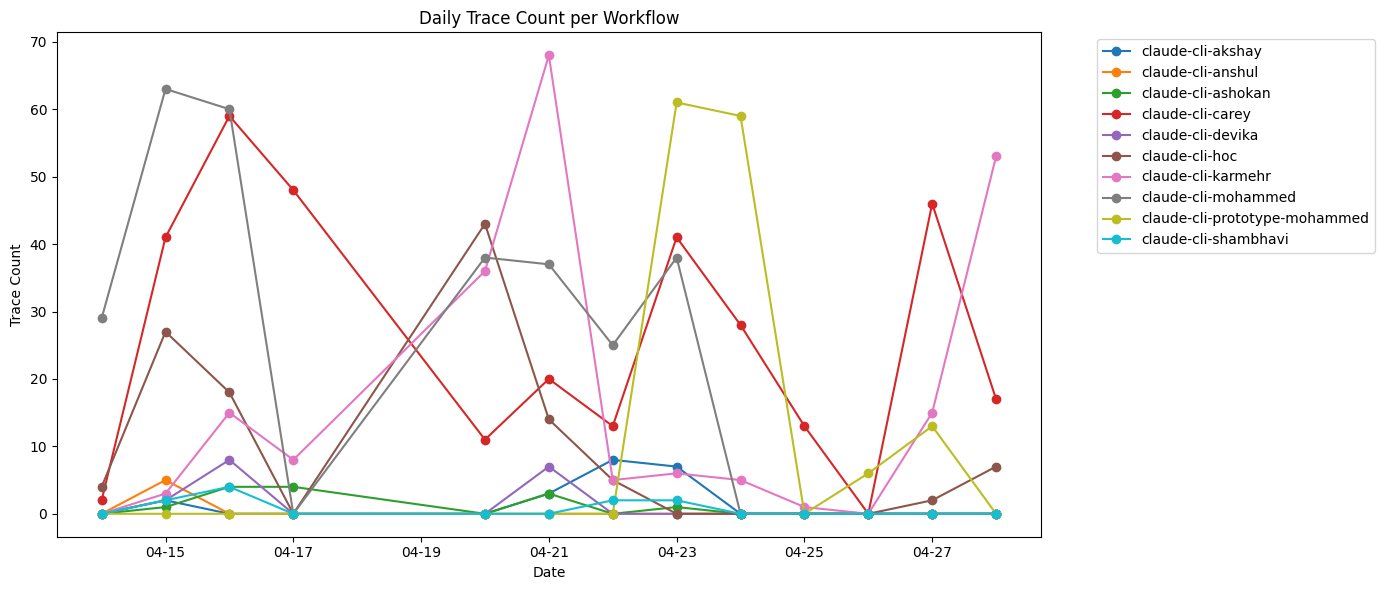

In [3]:
pivot_traces = df_traces.pivot(index="trace_date", columns="workflow_name", values="trace_count").fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
for col in pivot_traces.columns:
    ax.plot(pivot_traces.index, pivot_traces[col], marker="o", label=col)

ax.set_title("Daily Trace Count per Workflow")
ax.set_xlabel("Date")
ax.set_ylabel("Trace Count")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

---
## 2. Token Usage

In [4]:
tokens_sql = f"""
WITH {WORKFLOW_CTE},
{INFERENCE_CTE}
SELECT w.workflow_name,
       w.trace_date,
       SUM(i.total_input_tokens + i.completion_tokens) AS daily_total_tokens,
       SUM(i.total_input_tokens) AS daily_input_tokens,
       SUM(i.completion_tokens) AS daily_completion_tokens
FROM workflows w
JOIN inference_spans i ON w.trace_id = i.trace_id
GROUP BY 1, 2
ORDER BY 2, 1
"""

df_tokens = client.query(tokens_sql).to_dataframe()
df_tokens["trace_date"] = pd.to_datetime(df_tokens["trace_date"])
df_tokens

,workflow_name,trace_date,daily_total_tokens,daily_input_tokens,daily_completion_tokens
0,claude-cli-carey,2026-04-14,90009,89052,957
1,claude-cli-hoc,2026-04-14,81081,80866,215
2,claude-cli-mohammed,2026-04-14,908121,901653,6468
3,claude-cli-akshay,2026-04-15,37580,36895,685
4,claude-cli-anshul,2026-04-15,206943,204930,2013
5,claude-cli-ashokan,2026-04-15,17180,17167,13
6,claude-cli-carey,2026-04-15,2301634,2292201,9433
7,claude-cli-devika,2026-04-15,60552,60520,32
8,claude-cli-hoc,2026-04-15,1059266,1050660,8606
9,claude-cli-karmehr,2026-04-15,65735,64668,1067


### Column definitions

| Column | Description |
|--------|-------------|
| **workflow_name** | Claude Code user identifier (`claude-cli-<user>`). |
| **trace_date** | Calendar date (UTC). |
| **daily_total_tokens** | Sum of `input + completion` tokens across **all** inference spans in **all** sessions for that workflow on that date. This is the total API token consumption. |
| **daily_input_tokens** | Sum of normalised input tokens (prompt tokens sent to the model, including cached). When old instrumentation is detected, this is reconstructed as `prompt + cache_read + cache_creation`. |
| **daily_completion_tokens** | Sum of completion (output) tokens generated by the model. |

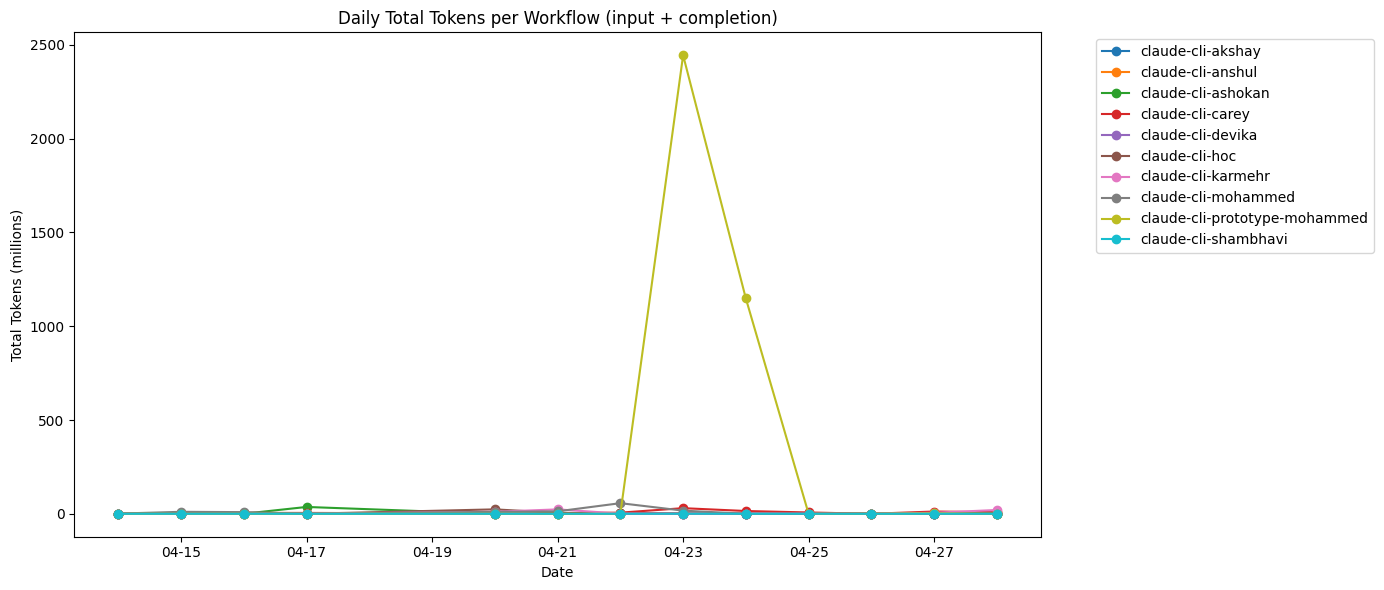

In [5]:
pivot_tokens = df_tokens.pivot(index="trace_date", columns="workflow_name", values="daily_total_tokens").fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
for col in pivot_tokens.columns:
    ax.plot(pivot_tokens.index, pivot_tokens[col] / 1_000_000, marker="o", label=col)

ax.set_title("Daily Total Tokens per Workflow (input + completion)")
ax.set_xlabel("Date")
ax.set_ylabel("Total Tokens (millions)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

---
## 3. Cache Hit Ratio

In [6]:
cache_sql = f"""
WITH {WORKFLOW_CTE},
{INFERENCE_CTE},
session_totals AS (
  SELECT w.workflow_name,
         w.trace_date,
         w.trace_id,
         SUM(i.total_input_tokens) AS session_input_tokens,
         SUM(COALESCE(i.cache_read_tokens, 0)) AS session_cache_read_tokens
  FROM workflows w
  JOIN inference_spans i ON w.trace_id = i.trace_id
  GROUP BY 1, 2, 3
)
SELECT workflow_name,
       trace_date,
       COUNT(*) AS session_count,
       ROUND(AVG(SAFE_DIVIDE(session_cache_read_tokens, session_input_tokens) * 100), 1) AS avg_cache_hit_pct,
       ROUND(MIN(SAFE_DIVIDE(session_cache_read_tokens, session_input_tokens) * 100), 1) AS min_cache_hit_pct,
       ROUND(MAX(SAFE_DIVIDE(session_cache_read_tokens, session_input_tokens) * 100), 1) AS max_cache_hit_pct,
       ROUND(SAFE_DIVIDE(SUM(session_cache_read_tokens), SUM(session_input_tokens)) * 100, 1) AS weighted_cache_hit_pct
FROM session_totals
GROUP BY 1, 2
ORDER BY 2, 1
"""

df_cache = client.query(cache_sql).to_dataframe()
df_cache["trace_date"] = pd.to_datetime(df_cache["trace_date"])
df_cache

,workflow_name,trace_date,session_count,avg_cache_hit_pct,min_cache_hit_pct,max_cache_hit_pct,weighted_cache_hit_pct
0,claude-cli-carey,2026-04-14,2,91.7,84.7,98.8,88.5
1,claude-cli-hoc,2026-04-14,4,73.4,0.0,99.6,98.0
2,claude-cli-mohammed,2026-04-14,29,92.7,69.5,99.5,94.5
3,claude-cli-akshay,2026-04-15,2,79.5,69.1,89.8,80.0
4,claude-cli-anshul,2026-04-15,4,90.7,68.4,98.6,94.9
5,claude-cli-ashokan,2026-04-15,1,100.0,100.0,100.0,100.0
6,claude-cli-carey,2026-04-15,41,92.9,10.3,99.9,92.9
7,claude-cli-devika,2026-04-15,2,69.9,40.7,99.1,69.8
8,claude-cli-hoc,2026-04-15,27,83.2,0.0,99.7,89.9
9,claude-cli-karmehr,2026-04-15,3,92.5,80.8,98.4,92.2


### Column definitions

| Column | Description |
|--------|-------------|
| **workflow_name** | Claude Code user identifier (`claude-cli-<user>`). |
| **trace_date** | Calendar date (UTC). |
| **session_count** | Number of distinct sessions (traces) for that workflow on that date. |
| **avg_cache_hit_pct** | Simple average of per-session cache hit ratios. Each session's ratio = `cache_read_tokens / total_input_tokens * 100`. Treats every session equally regardless of size. |
| **min_cache_hit_pct** | Lowest per-session cache hit ratio observed that day. A 0% means at least one session had no cache hits (e.g. a cold start or very short session). |
| **max_cache_hit_pct** | Highest per-session cache hit ratio observed that day. |
| **weighted_cache_hit_pct** | Volume-weighted cache hit ratio: `SUM(cache_read_tokens) / SUM(total_input_tokens) * 100` across all sessions. Larger sessions contribute proportionally more. This is the most meaningful metric for cost analysis. |

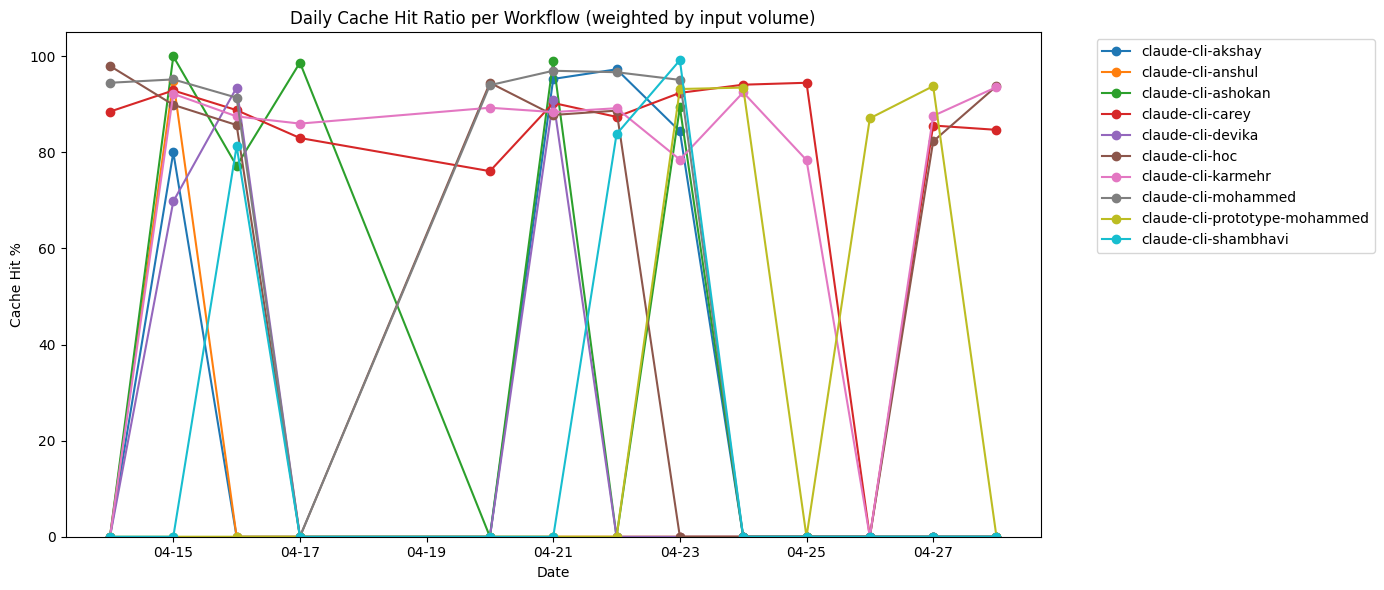

In [7]:
pivot_cache = df_cache.pivot(index="trace_date", columns="workflow_name", values="weighted_cache_hit_pct").fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
for col in pivot_cache.columns:
    ax.plot(pivot_cache.index, pivot_cache[col], marker="o", label=col)

ax.set_title("Daily Cache Hit Ratio per Workflow (weighted by input volume)")
ax.set_xlabel("Date")
ax.set_ylabel("Cache Hit %")
ax.set_ylim(0, 105)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

---
## 4. Git Push Audit

Detects `git push` operations from two sources:
1. **Bash CLI**: `Tool: Bash` spans where `events[0].attributes.input` contains `git push`
2. **GitHub MCP**: `Tool: mcp__plugin_github_github__*` spans (PR creation, etc.)

Joined to the parent workflow span to identify which user triggered the push.

In [8]:
git_push_sql = f"""
WITH pushes AS (
  -- Bash git push commands
  SELECT trace_id,
         span_id,
         start_time,
         'bash' AS source,
         JSON_VALUE(events, '$[0].attributes.input') AS raw_input,
         JSON_VALUE(events, '$[1].attributes.response') AS output
  FROM `{TABLE}`
  WHERE start_time >= TIMESTAMP_SUB(CURRENT_TIMESTAMP(), INTERVAL 14 DAY)
    AND name = 'Tool: Bash'
    AND JSON_VALUE(events, '$[0].attributes.input') LIKE '%git push%'

  UNION ALL

  -- GitHub MCP tool calls (PR creation, etc.)
  SELECT trace_id,
         span_id,
         start_time,
         'github_mcp' AS source,
         JSON_VALUE(events, '$[0].attributes.input') AS raw_input,
         JSON_VALUE(events, '$[1].attributes.response') AS output
  FROM `{TABLE}`
  WHERE start_time >= TIMESTAMP_SUB(CURRENT_TIMESTAMP(), INTERVAL 14 DAY)
    AND name LIKE 'Tool: mcp__plugin_github_github__%'
),
wf AS (
  SELECT trace_id,
         JSON_VALUE(attributes, '$.entity[0].name') AS workflow_name
  FROM `{TABLE}`
  WHERE start_time >= TIMESTAMP_SUB(CURRENT_TIMESTAMP(), INTERVAL 14 DAY)
    AND name = 'workflow'
    AND JSON_VALUE(attributes, '$.entity[0].name') LIKE 'claude-cli-%'
)
SELECT p.start_time,
       wf.workflow_name,
       p.source,
       -- Extract the git push command from the JSON input
       REGEXP_EXTRACT(p.raw_input, r'git push[^"]*') AS push_command,
       SUBSTR(p.output, 1, 200) AS output_snippet,
       p.trace_id
FROM pushes p
JOIN wf ON p.trace_id = wf.trace_id
ORDER BY p.start_time DESC
"""

df_pushes = client.query(git_push_sql).to_dataframe()
print(f"{len(df_pushes)} git push events found")
df_pushes

21 git push events found


,start_time,workflow_name,source,push_command,output_snippet,trace_id
0,2026-04-21 15:33:25.582000+00:00,claude-cli-hoc,bash,git push origin hoc/claude-skill,[hoc/claude-skill f555d2b5] fix: trace_viewer ...,0x737e426fb1a1202fb0c6f971294a61ca
1,2026-04-21 14:28:57.889000+00:00,claude-cli-carey,github_mcp,None,Failed to start OAuth flow for plugin:github:g...,0xb73f0caf79858ad208ae8a9196a986ce
2,2026-04-21 09:23:27.917000+00:00,claude-cli-mohammed,bash,git push -u imohammed mohammed/claude-code-tok...,remote: \nremote: Create a pull request for 'm...,0x662ca3e751dfa77ea6b56fb7da71635d
3,2026-04-21 09:22:47.775000+00:00,claude-cli-mohammed,bash,git push -u origin mohammed/claude-code-token-...,Exit code 128\nremote: Permission to hocokahu/...,0x66ae988b2babcd532fe229ba7cf6a6d1
4,2026-04-21 04:35:23.887000+00:00,claude-cli-hoc,bash,git push origin hoc/claude-skill,[hoc/claude-skill 0a9e4ae4] docs: remove redun...,0xd98f4095ce30fea00d9173f9d3d49999
5,2026-04-21 03:41:01.785000+00:00,claude-cli-hoc,bash,git push origin hoc/claude-skill,[hoc/claude-skill 29a0c7b0] docs: change backe...,0xbedccc8292ee28ed995810c3a3a73d5e
6,2026-04-21 02:39:12.849000+00:00,claude-cli-hoc,bash,git push origin hoc/claude-skill,To https://github.com/hocokahu/monocle.git\n ...,0xec8477f2d5280d3350a2ed9b2732c787
7,2026-04-20 17:00:28.560000+00:00,claude-cli-hoc,bash,git push,[hoc/claude-skill 5f7a1209] feat: add sub-agen...,0xdd64dff26f93f3cee0ae5815ba7b97d1
8,2026-04-20 17:00:28.560000+00:00,claude-cli-hoc,bash,git push,[hoc/claude-skill 5f7a1209] feat: add sub-agen...,0x9e1282adf03c26751262a3f6c5b3d575
9,2026-04-20 17:00:18.028000+00:00,claude-cli-hoc,bash,git push,Exit code 128\nfatal: pathspec 'apptrace/src/m...,0xdd64dff26f93f3cee0ae5815ba7b97d1


### Column definitions

| Column | Description |
|--------|-------------|
| **start_time** | Timestamp (UTC) when the git push tool call was executed. |
| **workflow_name** | The Claude Code user who triggered the push (`claude-cli-<user>`). Derived by joining the push span's `trace_id` to the root workflow span. |
| **source** | How the push was executed: `bash` = Bash tool with `git push` command, `github_mcp` = GitHub MCP plugin tool call (e.g. `gh pr create`). |
| **push_command** | The extracted `git push ...` command string, including remote and branch. |
| **output_snippet** | First 200 chars of the tool's output/response. Shows success messages or errors. |
| **trace_id** | Links back to the full session trace for deeper investigation. |